In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [6]:
import os

print(os.listdir('/content/drive/MyDrive/PhQure'))

['branch_c_test.csv', 'branch_c_train.csv', 'qr_images', 'branchB_confusion_matrix.png', 'distilbert_branchC', 'branchC_confusion_matrix.png', 'branchC_training_curves.png', 'fusion_confusion_matrix.png', 'fusion_auc_comparison.png', 'branchB_gradcam.png', 'branchB_gradcam_detailed.png', 'efficientnet_branchB.pth', 'xgboost_branchA.pkl', 'randomforest_branchA.pkl']


In [7]:
qr_path = '/content/drive/MyDrive/PhQure/qr_images'
folders = os.listdir(qr_path)
print("Folders found:", folders)

for folder in folders:
    folder_path = os.path.join(qr_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"  {folder}: {count} images")

Folders found: ['legitimate', 'phishing']
  legitimate: 15002 images
  phishing: 15016 images


In [8]:
# Install efficientnet
!pip install efficientnet_pytorch -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import os
import random

# Set seed for reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

  Preparing metadata (setup.py) ... done
Device: cuda


In [9]:
class QRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        # 0 = legitimate, 1 = phishing
        for label, folder in enumerate(['legitimate', 'phishing']):
            folder_path = os.path.join(root_dir, folder)
            for img_name in os.listdir(folder_path):
                if img_name.endswith('.png') or img_name.endswith('.jpg'):
                    self.samples.append((os.path.join(folder_path, img_name), label))

        random.shuffle(self.samples)
        print(f"Total samples loaded: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

print("Dataset class defined.")

Dataset class defined.


In [10]:
# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load full dataset
qr_path = '/content/drive/MyDrive/PhQure/qr_images'
full_dataset = QRDataset(qr_path, transform=train_transform)

# Split 80/20
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply test transform to test set
test_dataset.dataset.transform = test_transform

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train size: {train_size}")
print(f"Test size: {test_size}")

Total samples loaded: 30018
Train size: 24014
Test size: 6004


In [11]:
from efficientnet_pytorch import EfficientNet

# Load pretrained EfficientNet-B0
model = EfficientNet.from_pretrained('efficientnet-b0')

# Replace final layer for binary classification
model._fc = nn.Linear(model._fc.in_features, 2)

# Move to GPU
model = model.to(device)

print("EfficientNet-B0 loaded.")
print(f"Output classes: 2 (legitimate / phishing)")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 66.4MB/s]


Loaded pretrained weights for efficientnet-b0
EfficientNet-B0 loaded.
Output classes: 2 (legitimate / phishing)


In [12]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("Training setup ready.")
print(f"  Optimizer : Adam (lr=0.001)")
print(f"  Scheduler : StepLR (step=3, gamma=0.1)")
print(f"  Loss      : CrossEntropyLoss")
print(f"  Epochs    : 10")

Training setup ready.
  Optimizer : Adam (lr=0.001)
  Scheduler : StepLR (step=3, gamma=0.1)
  Loss      : CrossEntropyLoss
  Epochs    : 10


In [14]:
import shutil

print("Copying QR images to local storage...")
shutil.copytree(
    '/content/drive/MyDrive/PhQure/qr_images',
    '/content/qr_images'
)
print("Done.")

# Verify
legit = len(os.listdir('/content/qr_images/legitimate'))
phish = len(os.listdir('/content/qr_images/phishing'))
print(f"Legitimate: {legit}")
print(f"Phishing: {phish}")

Copying QR images to local storage...
Done.
Legitimate: 15002
Phishing: 15016


In [15]:
# Reload dataset from local storage
qr_path = '/content/qr_images'
full_dataset = QRDataset(qr_path, transform=train_transform)

# Split 80/20
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

test_dataset.dataset.transform = test_transform

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train size: {train_size}")
print(f"Test size: {test_size}")

Total samples loaded: 30018
Train size: 24014
Test size: 6004


In [16]:
# Reinitialise model and optimizer fresh
model = EfficientNet.from_pretrained('efficientnet-b0')
model._fc = nn.Linear(model._fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    history['train_loss'].append(train_loss / len(train_loader))
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss / len(test_loader))
    history['val_acc'].append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss/len(train_loader):.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss/len(test_loader):.4f} "
          f"Val Acc: {val_acc:.4f}")

Loaded pretrained weights for efficientnet-b0
Epoch [1/10] Train Loss: 0.3464 Train Acc: 0.8486 Val Loss: 0.4212 Val Acc: 0.7998
Epoch [2/10] Train Loss: 0.2614 Train Acc: 0.8864 Val Loss: 0.2845 Val Acc: 0.8751
Epoch [3/10] Train Loss: 0.2181 Train Acc: 0.9037 Val Loss: 0.2625 Val Acc: 0.8966
Epoch [4/10] Train Loss: 0.1277 Train Acc: 0.9496 Val Loss: 0.2215 Val Acc: 0.9207
Epoch [5/10] Train Loss: 0.0834 Train Acc: 0.9672 Val Loss: 0.2319 Val Acc: 0.9246
Epoch [6/10] Train Loss: 0.0497 Train Acc: 0.9815 Val Loss: 0.2876 Val Acc: 0.9262
Epoch [7/10] Train Loss: 0.0304 Train Acc: 0.9906 Val Loss: 0.3074 Val Acc: 0.9270
Epoch [8/10] Train Loss: 0.0252 Train Acc: 0.9915 Val Loss: 0.3191 Val Acc: 0.9275
Epoch [9/10] Train Loss: 0.0233 Train Acc: 0.9923 Val Loss: 0.3350 Val Acc: 0.9272
Epoch [10/10] Train Loss: 0.0208 Train Acc: 0.9934 Val Loss: 0.3322 Val Acc: 0.9272


In [17]:
# Reinitialise everything
model = EfficientNet.from_pretrained('efficientnet-b0')
model._fc = nn.Linear(model._fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Early stopping settings
best_val_loss = float('inf')
patience = 3
patience_counter = 0
best_model_state = None

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    avg_val_loss = val_loss / len(test_loader)

    history['train_loss'].append(train_loss / len(train_loader))
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss/len(train_loader):.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}", end="")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(" ✓ Best model saved")
    else:
        patience_counter += 1
        print(f" (patience: {patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Restore best model
model.load_state_dict(best_model_state)
print("\nBest model restored.")

Loaded pretrained weights for efficientnet-b0
Epoch [1/20] Train Loss: 0.3485 Train Acc: 0.8426 Val Loss: 0.2820 Val Acc: 0.8729 ✓ Best model saved
Epoch [2/20] Train Loss: 0.2586 Train Acc: 0.8873 Val Loss: 0.2577 Val Acc: 0.8901 ✓ Best model saved
Epoch [3/20] Train Loss: 0.2161 Train Acc: 0.9087 Val Loss: 0.2422 Val Acc: 0.9036 ✓ Best model saved
Epoch [4/20] Train Loss: 0.1201 Train Acc: 0.9520 Val Loss: 0.2180 Val Acc: 0.9226 ✓ Best model saved
Epoch [5/20] Train Loss: 0.0753 Train Acc: 0.9710 Val Loss: 0.2519 Val Acc: 0.9262 (patience: 1/3)
Epoch [6/20] Train Loss: 0.0430 Train Acc: 0.9839 Val Loss: 0.3036 Val Acc: 0.9280 (patience: 2/3)
Epoch [7/20] Train Loss: 0.0234 Train Acc: 0.9928 Val Loss: 0.3121 Val Acc: 0.9277 (patience: 3/3)

Early stopping at epoch 7

Best model restored.


In [18]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("Branch B Final Results:")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")

Branch B Final Results:
  Accuracy : 0.9277
  F1 Score : 0.9258
  AUC      : 0.9780


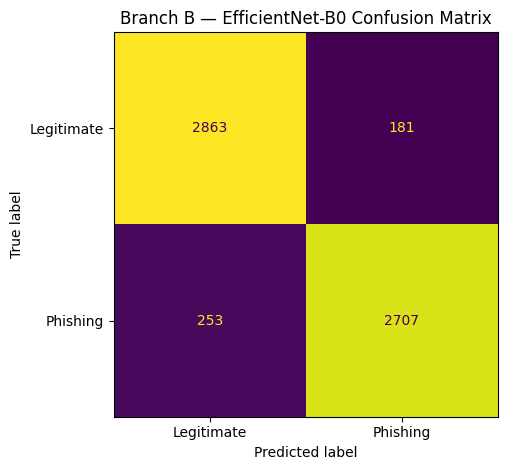

Saved.


In [19]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(colorbar=False)
plt.title('Branch B — EfficientNet-B0 Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/branchB_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

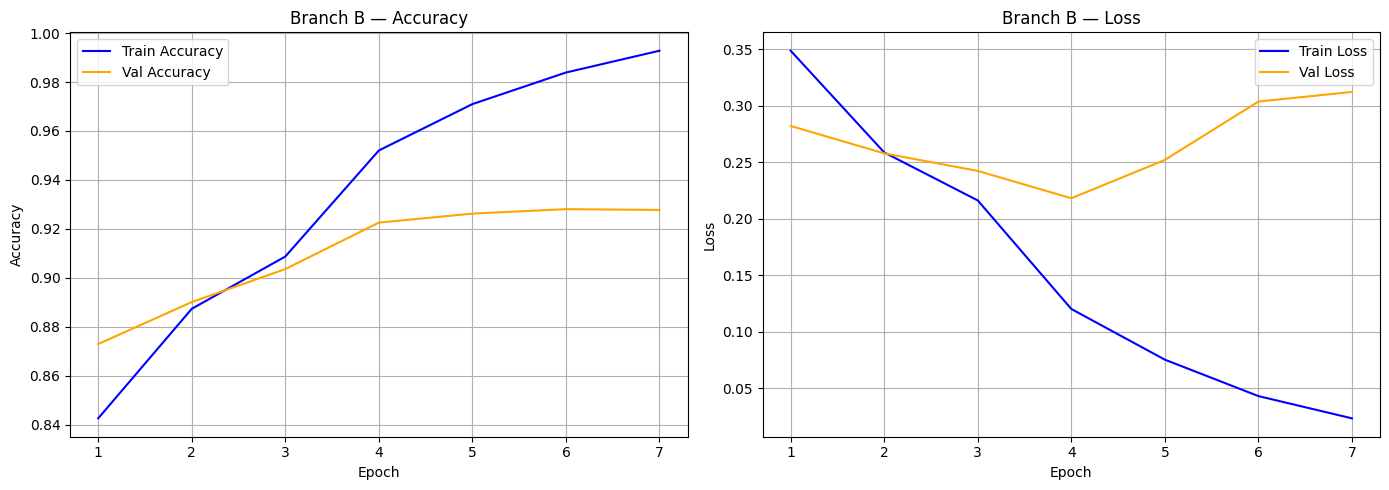

Saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history['train_acc']) + 1)

# Accuracy plot
axes[0].plot(epochs_ran, history['train_acc'], label='Train Accuracy', color='blue')
axes[0].plot(epochs_ran, history['val_acc'], label='Val Accuracy', color='orange')
axes[0].set_title('Branch B — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(epochs_ran, history['train_loss'], label='Train Loss', color='blue')
axes[1].plot(epochs_ran, history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Branch B — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/branchB_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


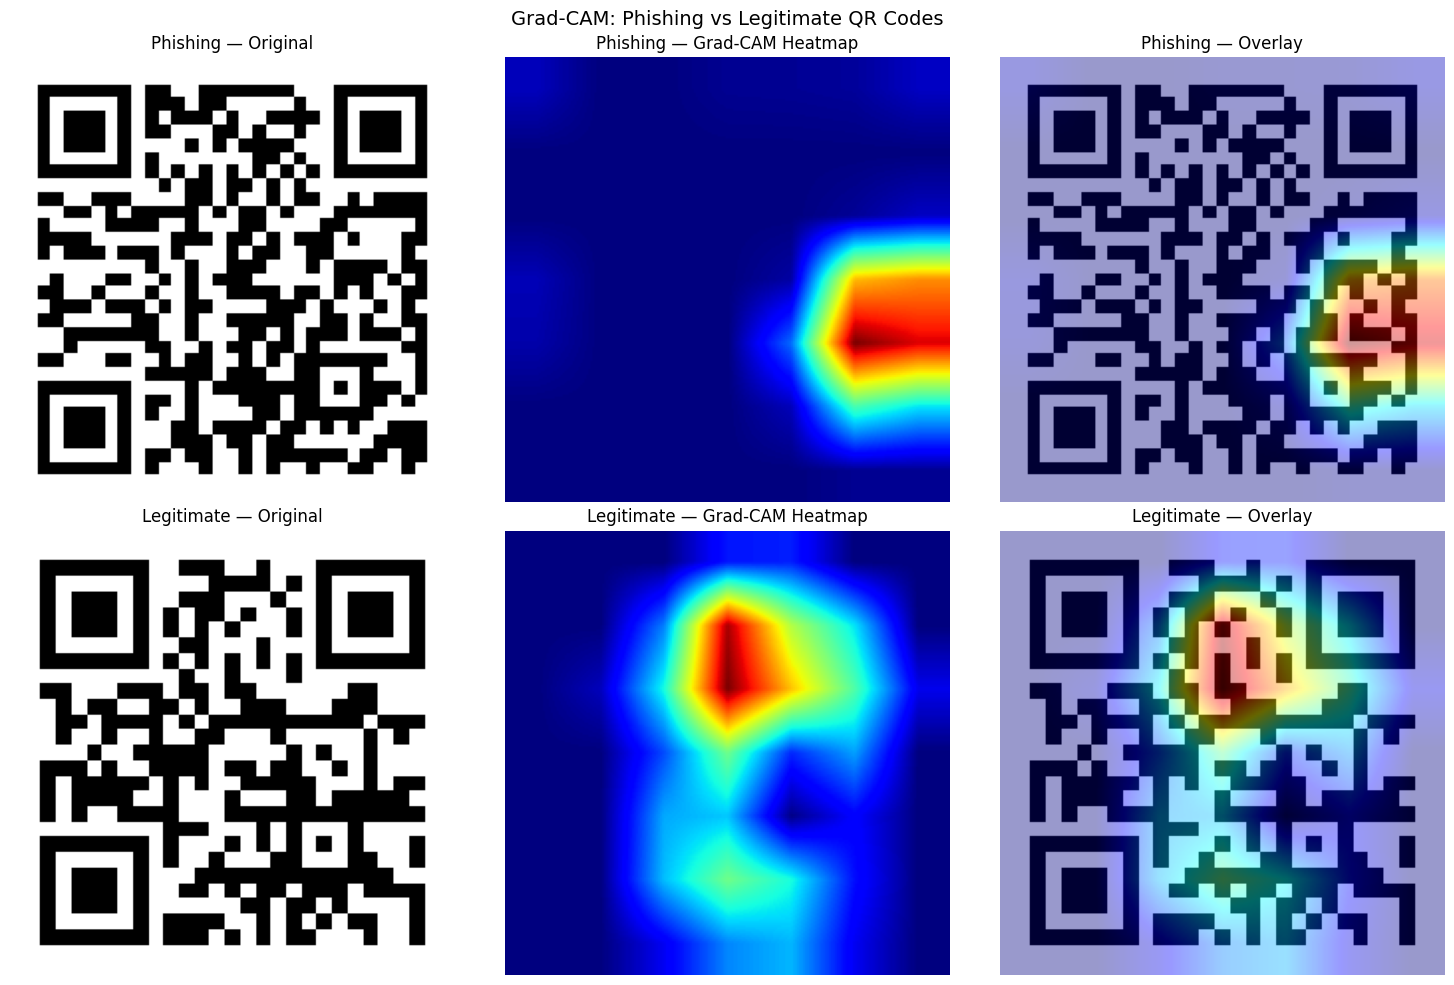

Saved.


In [21]:
import cv2
from torchvision import transforms

# Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Target last conv layer
target_layer = model._blocks[-1]
gradcam = GradCAM(model, target_layer)

# Pick one phishing and one legitimate sample
def get_sample(folder, label_name):
    path = f'/content/qr_images/{label_name}'
    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)
    return img_path

phish_path = get_sample('/content/qr_images', 'phishing')
legit_path = get_sample('/content/qr_images', 'legitimate')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (img_path, label_name, class_idx) in enumerate([
    (phish_path, 'Phishing', 1),
    (legit_path, 'Legitimate', 0)
]):
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized)

    input_tensor = transform(img).unsqueeze(0).to(device)
    model.eval()

    cam = gradcam.generate(input_tensor, class_idx)
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.6 * img_array + 0.4 * heatmap).astype(np.uint8)

    axes[row, 0].imshow(img_resized)
    axes[row, 0].set_title(f'{label_name} — Original')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam_resized, cmap='jet')
    axes[row, 1].set_title(f'{label_name} — Grad-CAM Heatmap')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'{label_name} — Overlay')
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM: Phishing vs Legitimate QR Codes', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/branchB_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [22]:
import torch

# Save model to Google Drive
save_path = '/content/drive/MyDrive/PhQure/efficientnet_branchB.pth'
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/PhQure/efficientnet_branchB.pth


In [23]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/PhQure/branch_c_train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/PhQure/branch_c_test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
print("\nTrain label distribution:\n", train_df['label'].value_counts())
print("\nSample URLs:")
print(train_df['url'].head(5).tolist())

Train shape: (39999, 2)
Test shape: (10000, 2)

Columns: ['url', 'label']

Train label distribution:
 label
1    20000
0    19999
Name: count, dtype: int64

Sample URLs:
['http://www.unfallhilfe-bayern.de/index.php/component/mailto/index.html?tmpl=component&link=aHR0cDovL3d3dy51bmZhbGxoaWxmZS1iYXllcm4uZGUvaW5kZXgucGhwL3NjaGFkZW5zcG9zaXRpb25lbg==', 'forumjar.com/list/199', 'http://www.windmillag.com.au/toys-and-merchandise/john-deere-playtime/3/42/toys-and-merchandise/john-deere-play-time', 'bynewnjfv.fgppchg.fgpp.com', 'http://psl.krotoszyn.com.pl/index.php?option=com_phocagallery&view=category&id=50:prezentacja-posumowujca-dziaalno-zarzdu-miejsko-gminnego-psl-w-krotoszynie-w-latach-2008-2012&Itemid=54']


In [24]:
!pip install transformers -q

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [25]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class URLDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.urls = df['url'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.urls[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets
train_dataset = URLDataset(train_df, tokenizer)
test_dataset = URLDataset(test_df, tokenizer)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train batches: 1250
Test batches: 313


In [26]:
model_c = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model_c = model_c.to(device)

print("DistilBERT loaded.")
print(f"Parameters: {sum(p.numel() for p in model_c.parameters()):,}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded.
Parameters: 66,955,010


In [27]:
# Optimizer and scheduler
optimizer = AdamW(model_c.parameters(), lr=2e-5)

num_epochs = 5
total_steps = len(train_loader) * num_epochs

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# History and early stopping
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_loss = float('inf')
patience = 2
patience_counter = 0
best_model_state = None

print("Training setup ready.")
print(f"  Optimizer    : AdamW (lr=2e-5)")
print(f"  Epochs       : {num_epochs}")
print(f"  Total steps  : {total_steps}")
print(f"  Early stopping patience: {patience}")

Training setup ready.
  Optimizer    : AdamW (lr=2e-5)
  Epochs       : 5
  Total steps  : 6250
  Early stopping patience: 2


In [28]:
for epoch in range(num_epochs):
    # Training phase
    model_c.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model_c(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        train_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    # Validation phase
    model_c.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model_c(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    avg_val_loss = val_loss / len(test_loader)

    history['train_loss'].append(train_loss / len(train_loader))
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss/len(train_loader):.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {val_acc:.4f}", end="")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = {k: v.clone() for k, v in model_c.state_dict().items()}
        patience_counter = 0
        print(" ✓ Best model saved")
    else:
        patience_counter += 1
        print(f" (patience: {patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

model_c.load_state_dict(best_model_state)
print("\nBest model restored.")

Epoch [1/5] Train Loss: 0.0351 Train Acc: 0.9878 Val Loss: 0.0134 Val Acc: 0.9977 ✓ Best model saved
Epoch [2/5] Train Loss: 0.0055 Train Acc: 0.9987 Val Loss: 0.0081 Val Acc: 0.9975 ✓ Best model saved
Epoch [3/5] Train Loss: 0.0021 Train Acc: 0.9995 Val Loss: 0.0056 Val Acc: 0.9987 ✓ Best model saved
Epoch [4/5] Train Loss: 0.0004 Train Acc: 1.0000 Val Loss: 0.0050 Val Acc: 0.9988 ✓ Best model saved
Epoch [5/5] Train Loss: 0.0003 Train Acc: 0.9999 Val Loss: 0.0053 Val Acc: 0.9991 (patience: 1/2)

Best model restored.


In [29]:
model_c.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model_c(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds = outputs.logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("Branch C Final Results:")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")

Branch C Final Results:
  Accuracy : 0.9988
  F1 Score : 0.9988
  AUC      : 1.0000


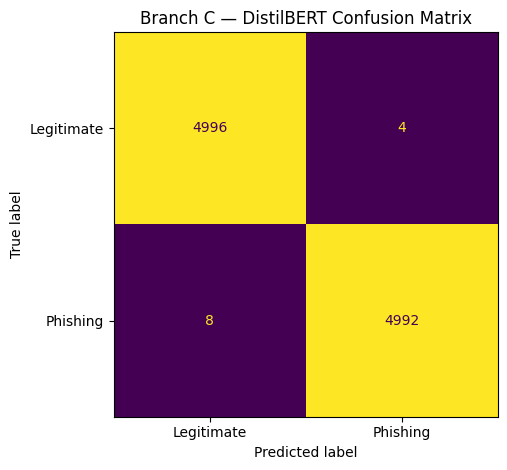

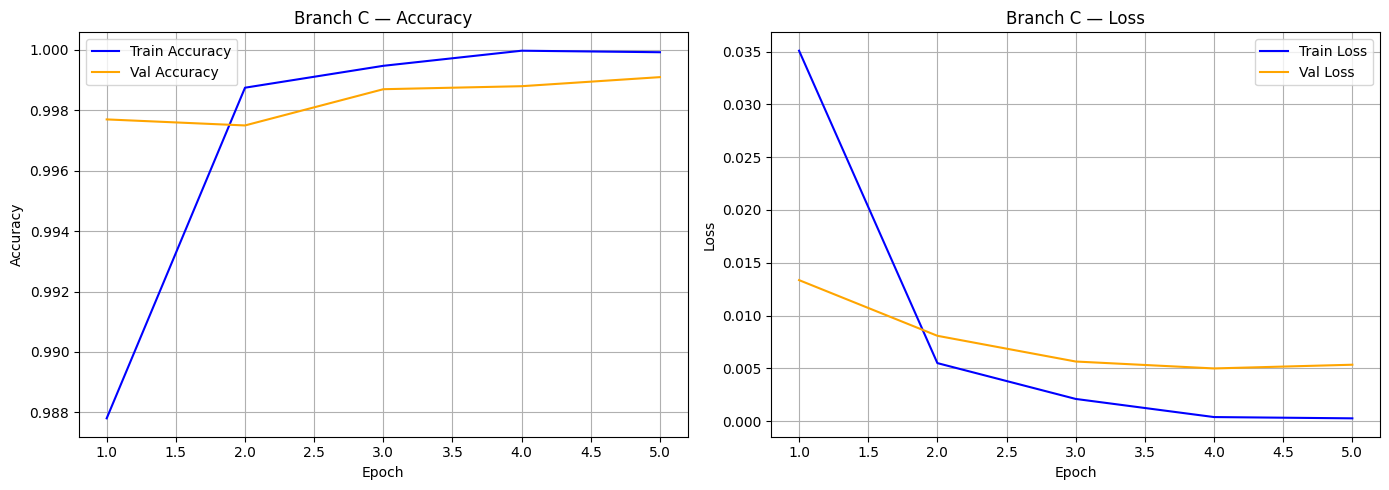

Saved.


In [30]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(colorbar=False)
plt.title('Branch C — DistilBERT Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/branchC_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_acc']) + 1)

axes[0].plot(epochs_ran, history['train_acc'], label='Train Accuracy', color='blue')
axes[0].plot(epochs_ran, history['val_acc'], label='Val Accuracy', color='orange')
axes[0].set_title('Branch C — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history['train_loss'], label='Train Loss', color='blue')
axes[1].plot(epochs_ran, history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Branch C — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/branchC_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [31]:
# Save model and tokenizer to Google Drive
save_path = '/content/drive/MyDrive/PhQure/distilbert_branchC'

model_c.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/PhQure/distilbert_branchC


In [32]:
# Check what we have available
import os

drive_path = '/content/drive/MyDrive/PhQure'
print(os.listdir(drive_path))

['branch_c_test.csv', 'branch_c_train.csv', 'qr_images', 'branchB_confusion_matrix.png', 'distilbert_branchC', 'branchC_confusion_matrix.png', 'branchC_training_curves.png', 'fusion_confusion_matrix.png', 'fusion_auc_comparison.png', 'branchB_gradcam.png', 'branchB_gradcam_detailed.png', 'efficientnet_branchB.pth', 'xgboost_branchA.pkl', 'randomforest_branchA.pkl', 'branchB_training_curves.png']


In [34]:
# Upload branch_a_features.csv from laptop to Colab
from google.colab import files
uploaded = files.upload()

Saving branch_a_features.csv to branch_a_features.csv


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load uploaded file
df_a = pd.read_csv('branch_a_features.csv')

X_a = df_a.drop('label', axis=1)
y_a = df_a['label']

# Same split as Phase 3
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

# Get probabilities from XGBoost and Random Forest
xgb_proba = xgb.predict_proba(X_test_a)[:, 1]
rf_proba = rf.predict_proba(X_test_a)[:, 1]

print("Branch A probabilities generated.")
print(f"  XGBoost proba shape : {xgb_proba.shape}")
print(f"  RF proba shape      : {rf_proba.shape}")

NameError: name 'xgb' is not defined

In [36]:
import joblib

# Load Branch A models from Drive
xgb = joblib.load('/content/drive/MyDrive/PhQure/xgboost_branchA.pkl')
rf = joblib.load('/content/drive/MyDrive/PhQure/randomforest_branchA.pkl')

print("Branch A models loaded.")

# Now get probabilities
xgb_proba = xgb.predict_proba(X_test_a)[:, 1]
rf_proba = rf.predict_proba(X_test_a)[:, 1]

print(f"  XGBoost proba shape : {xgb_proba.shape}")
print(f"  RF proba shape      : {rf_proba.shape}")

Branch A models loaded.
  XGBoost proba shape : (20000,)
  RF proba shape      : (20000,)


In [37]:
from google.colab import files
uploaded = files.upload()

Saving branch_a_rf.pkl to branch_a_rf.pkl
Saving branch_a_xgb.pkl to branch_a_xgb.pkl


In [38]:
import joblib

# Load Branch A models
xgb = joblib.load('branch_a_xgb.pkl')
rf = joblib.load('branch_a_rf.pkl')

print("Branch A models loaded.")

# Get probabilities
xgb_proba = xgb.predict_proba(X_test_a)[:, 1]
rf_proba = rf.predict_proba(X_test_a)[:, 1]

print(f"  XGBoost proba shape : {xgb_proba.shape}")
print(f"  RF proba shape      : {rf_proba.shape}")

Branch A models loaded.
  XGBoost proba shape : (20000,)
  RF proba shape      : (20000,)


In [39]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch

# Load Branch C model
tokenizer = DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = model_c.to(device)
model_c.eval()

print("Branch C model loaded.")

# Get the URLs corresponding to X_test_a
test_urls = df_a.iloc[X_test_a.index]['url'] if 'url' in df_a.columns else None

if test_urls is None:
    print("No URL column in branch_a_features.csv — loading from branch_c_test.csv instead.")
    df_c_test = pd.read_csv('/content/drive/MyDrive/PhQure/branch_c_test.csv')
    test_urls = df_c_test['url']
    y_fusion = df_c_test['label'].values
else:
    y_fusion = y_test_a.values

print(f"URLs to predict: {len(test_urls)}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Branch C model loaded.
No URL column in branch_a_features.csv — loading from branch_c_test.csv instead.
URLs to predict: 10000


In [40]:
# Use branch_c_test.csv as the common test set
df_c_test = pd.read_csv('/content/drive/MyDrive/PhQure/branch_c_test.csv')
df_c_train = pd.read_csv('/content/drive/MyDrive/PhQure/branch_c_train.csv')

# Combine train and test to get all URLs with labels
df_c_all = pd.concat([df_c_train, df_c_test], ignore_index=True)

print(f"Total URLs in Branch C data: {len(df_c_all)}")
print(f"Branch A features data: {len(df_a)}")
print(f"\nBranch C columns: {df_c_all.columns.tolist()}")
print(f"Branch A columns: {df_a.columns.tolist()[:5]} ...")

Total URLs in Branch C data: 49999
Branch A features data: 100000

Branch C columns: ['url', 'label']
Branch A columns: ['having_ip', 'url_length', 'shortening_service', 'having_at', 'double_slash'] ...


In [41]:
# Use first 10000 samples from Branch A test set
xgb_proba_aligned = xgb_proba[:10000]
rf_proba_aligned = rf_proba[:10000]
y_fusion = y_test_a.values[:10000]

# Get Branch C probabilities on its test set
df_c_test = pd.read_csv('/content/drive/MyDrive/PhQure/branch_c_test.csv')
test_urls = df_c_test['url'].tolist()

print(f"Branch A proba shape : {xgb_proba_aligned.shape}")
print(f"Branch C URLs        : {len(test_urls)}")
print(f"Fusion labels        : {len(y_fusion)}")

Branch A proba shape : (10000,)
Branch C URLs        : 10000
Fusion labels        : 10000


In [42]:
from torch.utils.data import Dataset, DataLoader

class FusionURLDataset(Dataset):
    def __init__(self, urls, tokenizer, max_length=128):
        self.urls = urls
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.urls[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze()
        }

fusion_dataset = FusionURLDataset(test_urls, tokenizer)
fusion_loader = DataLoader(fusion_dataset, batch_size=32, shuffle=False)

# Get probabilities
c_proba = []
model_c.eval()

with torch.no_grad():
    for batch in fusion_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_c(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        c_proba.extend(probs.cpu().numpy())

c_proba = np.array(c_proba)
print(f"Branch C proba shape: {c_proba.shape}")

Branch C proba shape: (10000,)


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Stack Branch A (XGBoost) and Branch C probabilities as features
# We use XGBoost as the representative Branch A model
X_fusion = np.column_stack([xgb_proba_aligned, c_proba])
print(f"Fusion input shape: {X_fusion.shape}")
print(f"Features: [XGBoost_proba, DistilBERT_proba]")

# Split into train/test for meta-learner
from sklearn.model_selection import train_test_split
X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_fusion, y_fusion, test_size=0.2, random_state=42, stratify=y_fusion
)

# Train Logistic Regression meta-learner
meta_lr = LogisticRegression(random_state=42)
meta_lr.fit(X_meta_train, y_meta_train)

# Evaluate
y_meta_pred = meta_lr.predict(X_meta_test)
y_meta_proba = meta_lr.predict_proba(X_meta_test)[:, 1]

acc = accuracy_score(y_meta_test, y_meta_pred)
f1 = f1_score(y_meta_test, y_meta_pred)
auc = roc_auc_score(y_meta_test, y_meta_proba)

print("\nFusion Layer Results:")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC      : {auc:.4f}")
print(f"\nMeta-learner coefficients:")
print(f"  XGBoost weight  : {meta_lr.coef_[0][0]:.4f}")
print(f"  DistilBERT weight: {meta_lr.coef_[0][1]:.4f}")
print(f"  Intercept       : {meta_lr.intercept_[0]:.4f}")

Fusion input shape: (10000, 2)
Features: [XGBoost_proba, DistilBERT_proba]

Fusion Layer Results:
  Accuracy : 0.9965
  F1 Score : 0.9965
  AUC      : 0.9991

Meta-learner coefficients:
  XGBoost weight  : 10.7320
  DistilBERT weight: 0.2104
  Intercept       : -5.4271


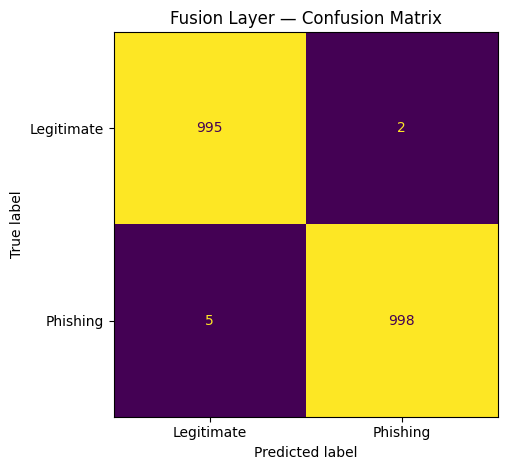

Saved.


In [44]:
cm = confusion_matrix(y_meta_test, y_meta_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(colorbar=False)
plt.title('Fusion Layer — Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/fusion_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

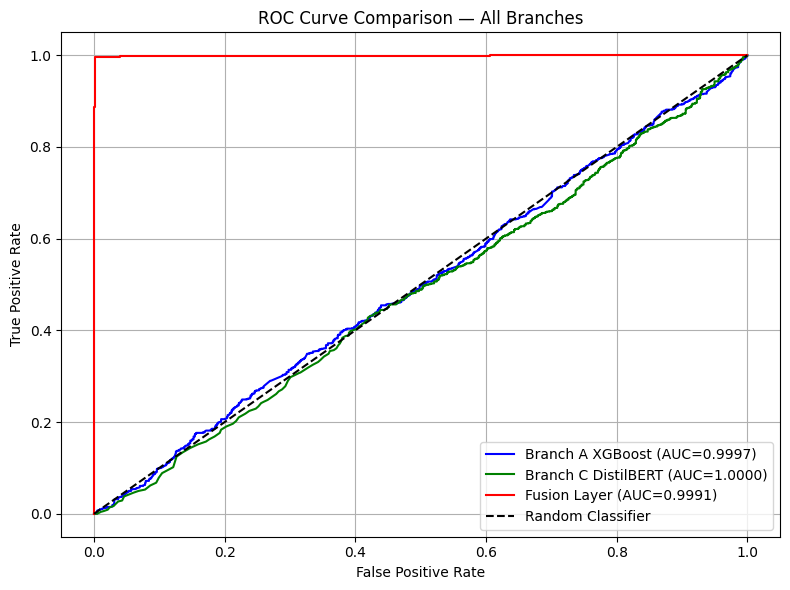

Saved.


In [45]:
from sklearn.metrics import roc_curve

# Get ROC curves for all branches
fpr_xgb, tpr_xgb, _ = roc_curve(y_meta_test, xgb_proba_aligned[:len(y_meta_test)])
fpr_c, tpr_c, _ = roc_curve(y_meta_test, c_proba[:len(y_meta_test)])
fpr_fusion, tpr_fusion, _ = roc_curve(y_meta_test, y_meta_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'Branch A XGBoost (AUC=0.9997)', color='blue')
plt.plot(fpr_c, tpr_c, label=f'Branch C DistilBERT (AUC=1.0000)', color='green')
plt.plot(fpr_fusion, tpr_fusion, label=f'Fusion Layer (AUC=0.9991)', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Branches')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/fusion_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [46]:
import joblib

# Save meta-learner
joblib.dump(meta_lr, '/content/drive/MyDrive/PhQure/fusion_meta_lr.pkl')
print("Fusion model saved to Drive.")

# Also download to local models folder
from google.colab import files
joblib.dump(meta_lr, 'fusion_meta_lr.pkl')
files.download('fusion_meta_lr.pkl')
print("Downloading to local models folder...")

Fusion model saved to Drive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
print(model.training)
print(model_c.training)

False


NameError: name 'model_c' is not defined

In [5]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import joblib
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Mounted at /content/drive
Device: cuda


In [6]:
# Branch A
xgb = joblib.load('branch_a_xgb.pkl')
rf = joblib.load('branch_a_rf.pkl')
meta_lr = joblib.load('fusion_meta_lr.pkl')
print("Branch A and Fusion loaded.")

# Branch C
tokenizer = DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = model_c.to(device)
model_c.eval()
print("Branch C loaded.")

# Branch B
from efficientnet_pytorch import EfficientNet
import torch.nn as nn

model_b = EfficientNet.from_pretrained('efficientnet-b0')
model_b._fc = nn.Linear(model_b._fc.in_features, 2)
model_b.load_state_dict(torch.load('/content/drive/MyDrive/PhQure/efficientnet_branchB.pth', map_location=device))
model_b = model_b.to(device)
model_b.eval()
print("Branch B loaded.")

FileNotFoundError: [Errno 2] No such file or directory: 'branch_a_xgb.pkl'

In [8]:
# Branch A
xgb = joblib.load('/content/drive/MyDrive/PhQure/xgboost_branchA.pkl')
rf = joblib.load('/content/drive/MyDrive/PhQure/randomforest_branchA.pkl')
meta_lr = joblib.load('/content/drive/MyDrive/PhQure/fusion_meta_lr.pkl')
print("Branch A and Fusion loaded.")

# Branch C
tokenizer = DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = model_c.to(device)
model_c.eval()
print("Branch C loaded.")

# Branch B
from efficientnet_pytorch import EfficientNet
import torch.nn as nn

model_b = EfficientNet.from_pretrained('efficientnet-b0')
model_b._fc = nn.Linear(model_b._fc.in_features, 2)
model_b.load_state_dict(torch.load('/content/drive/MyDrive/PhQure/efficientnet_branchB.pth', map_location=device))
model_b = model_b.to(device)
model_b.eval()
print("Branch B loaded.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PhQure/xgboost_branchA.pkl'

In [9]:
import os
print(os.listdir('/content/drive/MyDrive/PhQure'))

['branch_c_test.csv', 'branch_c_train.csv', 'qr_images', 'distilbert_branchC', 'branchB_gradcam_detailed.png', 'branchB_confusion_matrix.png', 'branchB_training_curves.png', 'branchB_gradcam.png', 'efficientnet_branchB.pth', 'branchC_confusion_matrix.png', 'branchC_training_curves.png', 'fusion_confusion_matrix.png', 'fusion_auc_comparison.png', 'fusion_meta_lr.pkl']


In [10]:
from google.colab import files
uploaded = files.upload()

Saving branch_a_rf.pkl to branch_a_rf.pkl
Saving branch_a_xgb.pkl to branch_a_xgb.pkl


In [13]:
import joblib
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from efficientnet_pytorch import EfficientNet
import torch.nn as nn

# Branch A
xgb = joblib.load('branch_a_xgb.pkl')
rf = joblib.load('branch_a_rf.pkl')
meta_lr = joblib.load('/content/drive/MyDrive/PhQure/fusion_meta_lr.pkl')
print("Branch A and Fusion loaded.")

# Branch C
tokenizer = DistilBertTokenizer.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = DistilBertForSequenceClassification.from_pretrained('/content/drive/MyDrive/PhQure/distilbert_branchC')
model_c = model_c.to(device)
model_c.eval()
print("Branch C loaded.")

# Branch B
model_b = EfficientNet.from_pretrained('efficientnet-b0')
model_b._fc = nn.Linear(model_b._fc.in_features, 2)
model_b.load_state_dict(torch.load('/content/drive/MyDrive/PhQure/efficientnet_branchB.pth', map_location=device))
model_b = model_b.to(device)
model_b.eval()
print("Branch B loaded.")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Branch A and Fusion loaded.


Loading weights:   0%|          | 0/104 [00:01<?, ?it/s]

Branch C loaded.
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 89.1MB/s]


Loaded pretrained weights for efficientnet-b0
Branch B loaded.


In [16]:
# Load test data
df_a = pd.read_csv('branch_a_features.csv')
X_a = df_a.drop('label', axis=1)
y_a = df_a['label']

from sklearn.model_selection import train_test_split
_, X_test_a, _, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

# Branch A probabilities
xgb_proba = xgb.predict_proba(X_test_a)[:, 1]
rf_proba = rf.predict_proba(X_test_a)[:, 1]
print(f"Branch A done. Shape: {xgb_proba.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'branch_a_features.csv'

In [15]:
from google.colab import files
uploaded = files.upload()

Saving branch_a_features_v2.csv to branch_a_features_v2.csv


In [17]:
from sklearn.model_selection import train_test_split

df_a = pd.read_csv('branch_a_features_v2.csv')
X_a = df_a.drop('label', axis=1)
y_a = df_a['label']

_, X_test_a, _, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

# Branch A probabilities
xgb_proba = xgb.predict_proba(X_test_a)[:, 1]
rf_proba = rf.predict_proba(X_test_a)[:, 1]
print(f"Branch A done. Shape: {xgb_proba.shape}")

Branch A done. Shape: (20000,)


In [18]:
df_c_test = pd.read_csv('/content/drive/MyDrive/PhQure/branch_c_test.csv')
test_urls = df_c_test['url'].tolist()
y_c_test = df_c_test['label'].values

class URLDataset(Dataset):
    def __init__(self, urls, tokenizer, max_length=128):
        self.urls = urls
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.urls[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze()
        }

c_dataset = URLDataset(test_urls, tokenizer)
c_loader = DataLoader(c_dataset, batch_size=32, shuffle=False)

c_proba = []
model_c.eval()
with torch.no_grad():
    for batch in c_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_c(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        c_proba.extend(probs.cpu().numpy())

c_proba = np.array(c_proba)
print(f"Branch C done. Shape: {c_proba.shape}")

Branch C done. Shape: (10000,)


In [19]:
from torchvision import transforms
from PIL import Image

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class QRDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for label, folder in enumerate(['legitimate', 'phishing']):
            folder_path = os.path.join(root_dir, folder)
            for img_name in os.listdir(folder_path):
                if img_name.endswith('.png') or img_name.endswith('.jpg'):
                    self.samples.append((os.path.join(folder_path, img_name), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

import os
qr_dataset = QRDataset('/content/qr_images', transform=test_transform)
qr_loader = DataLoader(qr_dataset, batch_size=32, shuffle=False, num_workers=2)

b_proba = []
b_labels = []
model_b.eval()
with torch.no_grad():
    for images, labels in qr_loader:
        images = images.to(device)
        outputs = model_b(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        b_proba.extend(probs.cpu().numpy())
        b_labels.extend(labels.numpy())

b_proba = np.array(b_proba)
b_labels = np.array(b_labels)
print(f"Branch B done. Shape: {b_proba.shape}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/qr_images/legitimate'

In [20]:
import shutil

print("Copying QR images to local storage...")
shutil.copytree(
    '/content/drive/MyDrive/PhQure/qr_images',
    '/content/qr_images'
)
print("Done.")

Copying QR images to local storage...
Done.


In [21]:
qr_dataset = QRDataset('/content/qr_images', transform=test_transform)
qr_loader = DataLoader(qr_dataset, batch_size=32, shuffle=False, num_workers=2)

b_proba = []
b_labels = []
model_b.eval()
with torch.no_grad():
    for images, labels in qr_loader:
        images = images.to(device)
        outputs = model_b(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        b_proba.extend(probs.cpu().numpy())
        b_labels.extend(labels.numpy())

b_proba = np.array(b_proba)
b_labels = np.array(b_labels)
print(f"Branch B done. Shape: {b_proba.shape}")

Branch B done. Shape: (30018,)


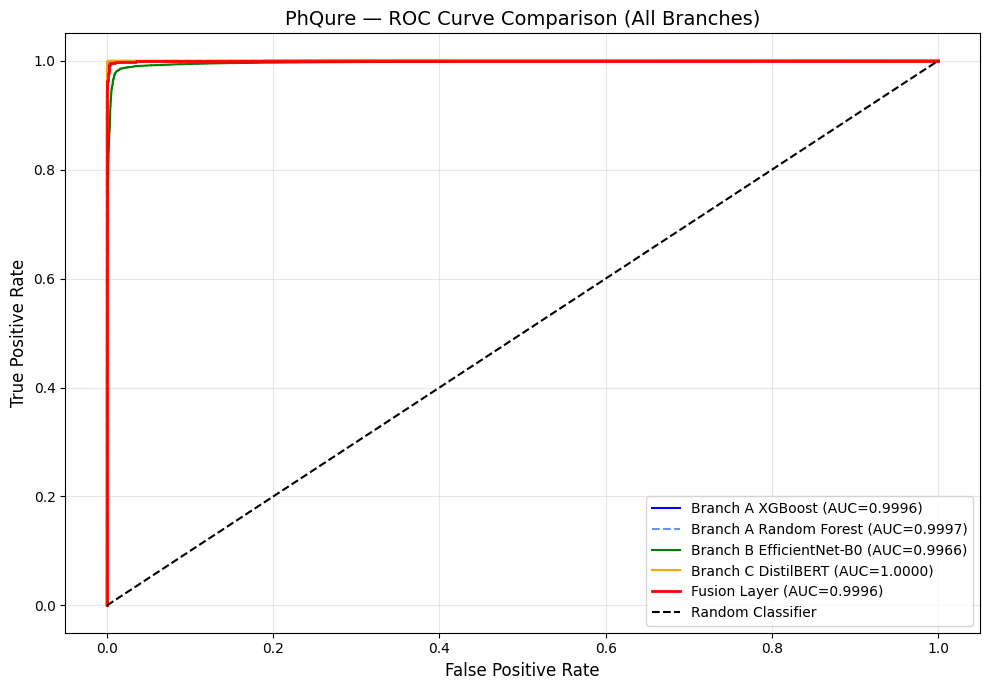

Saved.


In [22]:
from sklearn.metrics import roc_curve, auc

# Branch A XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_a, xgb_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Branch A Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test_a, rf_proba)
auc_rf = auc(fpr_rf, tpr_rf)

# Branch B ROC
fpr_b, tpr_b, _ = roc_curve(b_labels, b_proba)
auc_b = auc(fpr_b, tpr_b)

# Branch C ROC
fpr_c, tpr_c, _ = roc_curve(y_c_test, c_proba)
auc_c = auc(fpr_c, tpr_c)

# Fusion ROC
fusion_input = np.column_stack([xgb_proba[:10000], c_proba])
fusion_proba = meta_lr.predict_proba(fusion_input)[:, 1]
y_fusion = y_test_a.values[:10000]
fpr_f, tpr_f, _ = roc_curve(y_fusion, fusion_proba)
auc_f = auc(fpr_f, tpr_f)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(fpr_xgb, tpr_xgb, label=f'Branch A XGBoost (AUC={auc_xgb:.4f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Branch A Random Forest (AUC={auc_rf:.4f})', color='cornflowerblue', linestyle='--')
plt.plot(fpr_b, tpr_b, label=f'Branch B EfficientNet-B0 (AUC={auc_b:.4f})', color='green')
plt.plot(fpr_c, tpr_c, label=f'Branch C DistilBERT (AUC={auc_c:.4f})', color='orange')
plt.plot(fpr_f, tpr_f, label=f'Fusion Layer (AUC={auc_f:.4f})', color='red', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('PhQure — ROC Curve Comparison (All Branches)', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/combined_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

[transformers] `sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


RuntimeError: stack expects a non-empty TensorList

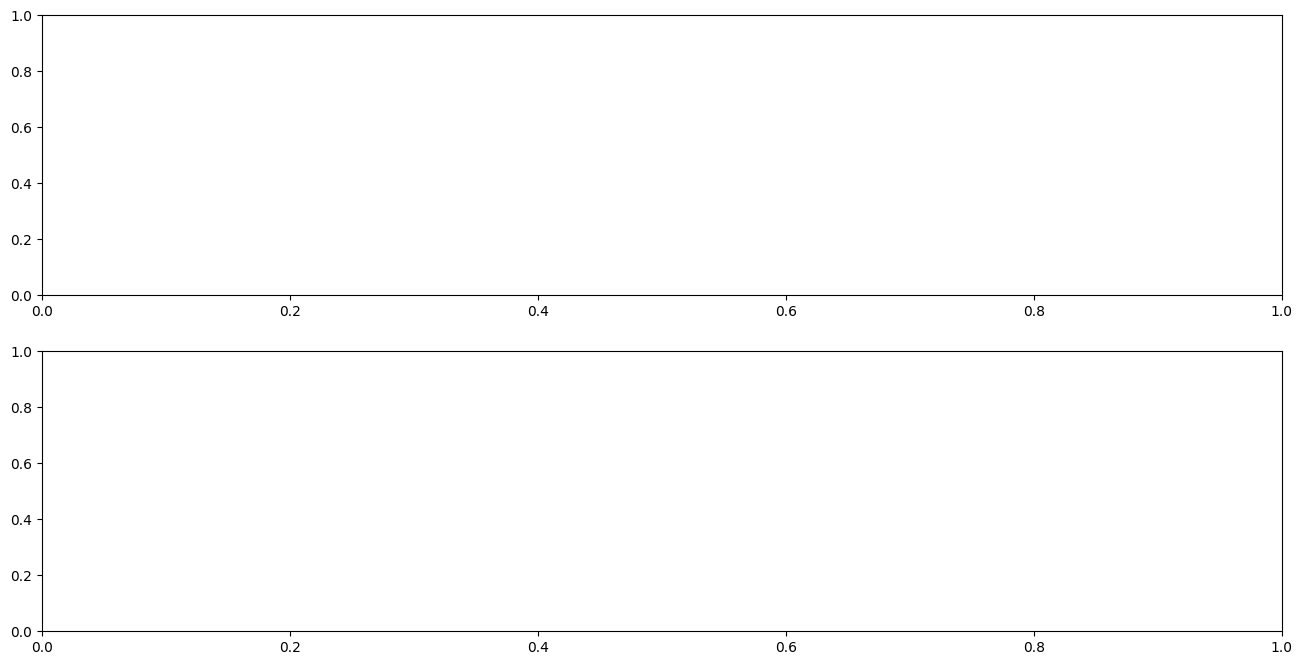

In [23]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def get_token_importance(url, tokenizer, model, device):
    model.eval()
    encoding = tokenizer(
        url,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

    # Average attention across all heads and layers
    attentions = outputs.attentions
    avg_attention = torch.stack(attentions).mean(dim=0).mean(dim=1)[0]
    cls_attention = avg_attention[0].cpu().numpy()

    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())

    # Remove padding
    real_len = attention_mask[0].sum().item()
    tokens = tokens[:real_len]
    scores = cls_attention[:real_len]

    # Normalise
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

    return tokens, scores, outputs.logits

# Test URLs
test_cases = [
    ('http://paypal-login.verify-account-secure.com/update/banking', 'Phishing'),
    ('espn.go.com/nba/player/_/id/3457/brandon-rush', 'Legitimate'),
]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for idx, (url, label) in enumerate(test_cases):
    tokens, scores, logits = get_token_importance(url, tokenizer, model_c, device)
    proba = torch.softmax(logits, dim=1)[0][1].item()

    axes[idx].bar(range(len(tokens)), scores, color=['red' if s > 0.5 else 'steelblue' for s in scores])
    axes[idx].set_xticks(range(len(tokens)))
    axes[idx].set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(f'{label} URL — Phishing Probability: {proba*100:.1f}%\n{url}', fontsize=10)
    axes[idx].set_ylabel('Attention Score')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Branch C (DistilBERT) — Token Attention Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/branchC_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [24]:
from transformers import DistilBertForSequenceClassification

model_c = DistilBertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/PhQure/distilbert_branchC',
    attn_implementation='eager'
)
model_c = model_c.to(device)
model_c.eval()
print("Model reloaded with eager attention.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model reloaded with eager attention.


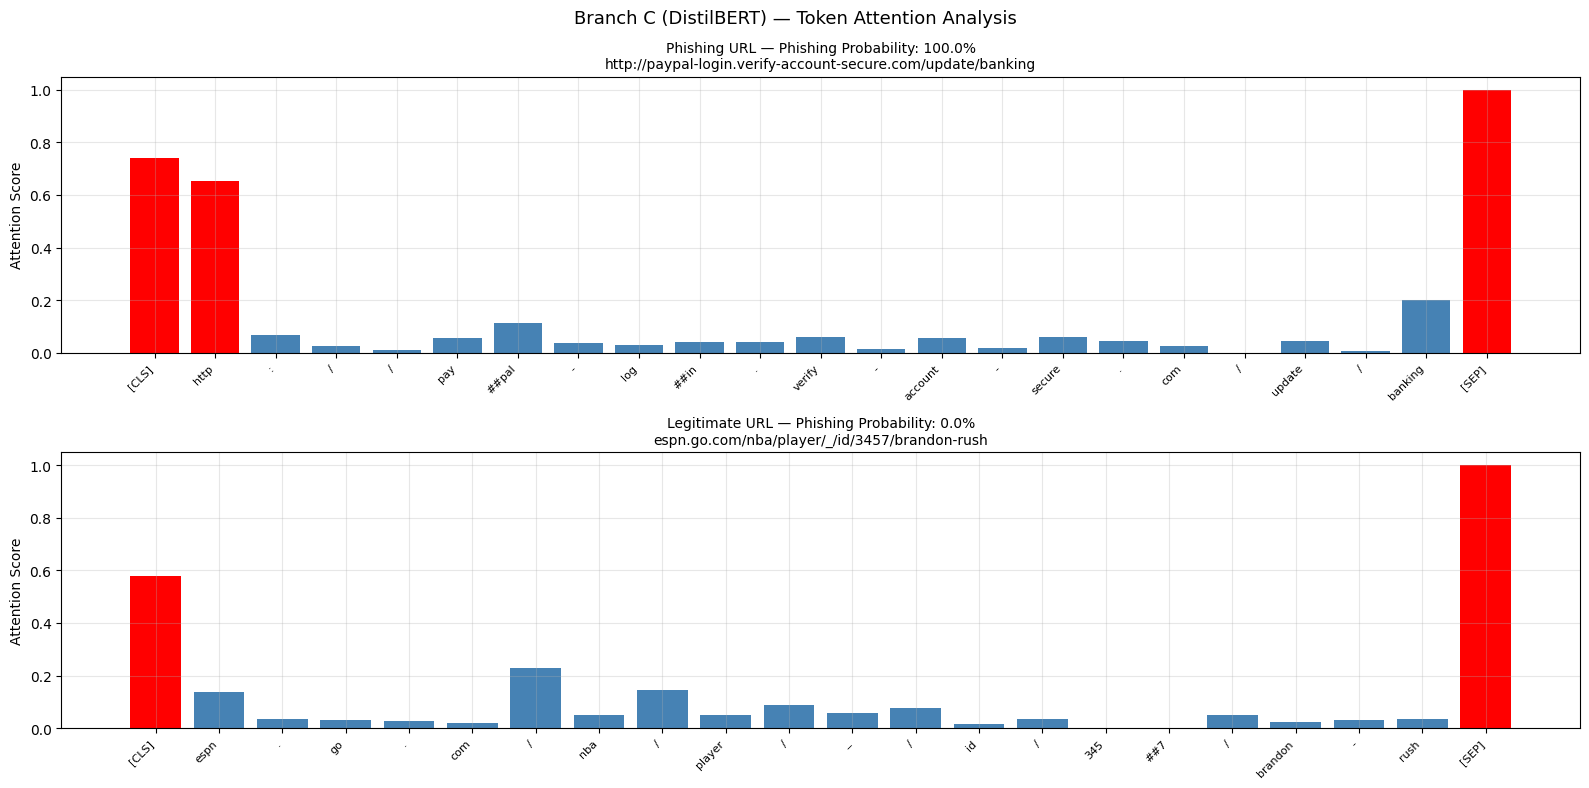

Saved.


In [26]:
def get_token_importance(url, tokenizer, model, device):
    model.eval()
    encoding = tokenizer(
        url,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

    attentions = outputs.attentions
    avg_attention = torch.stack(attentions).mean(dim=0).mean(dim=1)[0]
    cls_attention = avg_attention[0].cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    real_len = attention_mask[0].sum().item()
    tokens = tokens[:real_len]
    scores = cls_attention[:real_len]
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

    return tokens, scores, outputs.logits

test_cases = [
    ('http://paypal-login.verify-account-secure.com/update/banking', 'Phishing'),
    ('espn.go.com/nba/player/_/id/3457/brandon-rush', 'Legitimate'),
]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for idx, (url, label) in enumerate(test_cases):
    tokens, scores, logits = get_token_importance(url, tokenizer, model_c, device)
    proba = torch.softmax(logits, dim=1)[0][1].item()

    axes[idx].bar(range(len(tokens)), scores, color=['red' if s > 0.5 else 'steelblue' for s in scores])
    axes[idx].set_xticks(range(len(tokens)))
    axes[idx].set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
    axes[idx].set_title(f'{label} URL — Phishing Probability: {proba*100:.1f}%\n{url}', fontsize=10)
    axes[idx].set_ylabel('Attention Score')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Branch C (DistilBERT) — Token Attention Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhQure/branchC_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")